In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-pastel')

# Тестовые параметры из разностной схемы
N = 50
A = np.ones(N)       # Нижняя диагональ
B = -2 * np.ones(N)  # Главная диагональ
C = np.ones(N)       # Верхняя диагональ
D = -50 * np.ones(N) # Вектор правых частей (источник тепла)

# Граничные условия (Дирихле)
B[0] = 1; C[0] = 0; D[0] = 100
A[-1] = 0; B[-1] = 1; D[-1] = 20


In [2]:
def progonka(A, B, C, D):
    n = len(D)
    alpha = np.zeros(n)
    beta = np.zeros(n)
    y = np.zeros(n)

    # Прямой ход
    alpha[0] = -C[0] / B[0]
    beta[0] = D[0] / B[0]
    for i in range(1, n-1):
        denominator = B[i] + A[i] * alpha[i-1]
        alpha[i] = -C[i] / denominator
        beta[i] = (D[i] - A[i] * beta[i-1]) / denominator
    
    # Для последнего элемента
    beta[n-1] = (D[n-1] - A[n-1] * beta[n-2]) / (B[n-1] + A[n-1] * alpha[n-2])

    # Обратный ход
    y[n-1] = beta[n-1]
    for i in range(n-2, -1, -1):
        y[i] = alpha[i] * y[i+1] + beta[i]

    return y


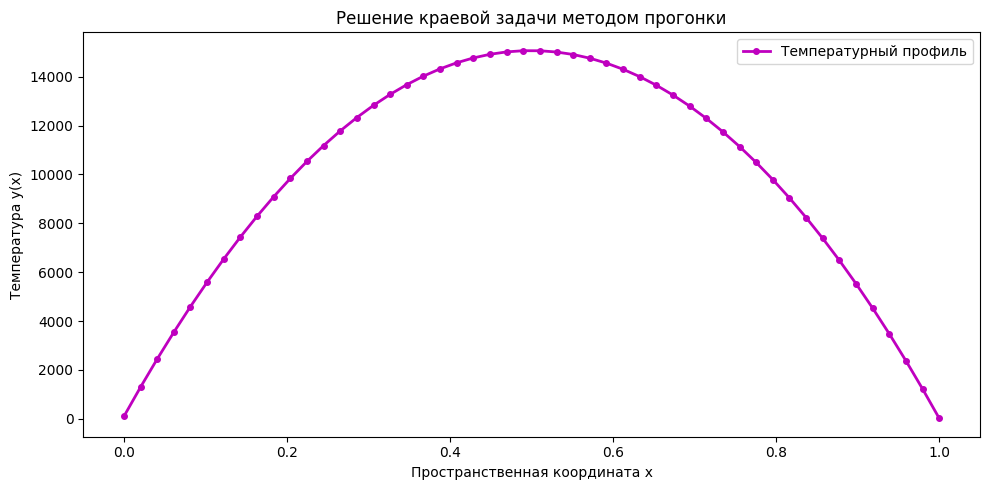

In [3]:
y = progonka(A, B, C, D)
x = np.linspace(0, 1, N)

plt.figure(figsize=(10, 5))
plt.plot(x, y, 'm-o', linewidth=2, markersize=4, label='Температурный профиль')
plt.title('Решение краевой задачи методом прогонки')
plt.xlabel('Пространственная координата x')
plt.ylabel('Температура y(x)')
plt.legend()
plt.tight_layout()
plt.show()
